# CRF (Conditional Response Function) — Stim Coding z-bias 仿真

**实验范式**: Self Matching Task (Sui, 2012)

**仿真原理**: Stim Coding — 通过操纵 DDM 起始点参数 z 模拟匹配键偏好

**CRF 逻辑**: 按反应时(RT)分位数分箱，每箱计算 P(Matching)，刻画决策倾向随反应速度的动态变化

---

## Docker 启动方式

```bash
docker pull hcp4715/hddm

docker run -it --rm --cpus=4 ^
  -v /d/GitHub_programe/GitHub/Guassion-Process-Experiment-Design:/home/jovyan/work ^
  -p 8888:8888 ^
  hcp4715/hddm ^
  jupyter notebook
```

---

## 工作流

| Cell | 内容 |
|------|------|
| Cell 1 | 环境配置与包导入 |
| Cell 2 | 数据生成函数定义 (Wiener DDM + Stim Coding) |
| Cell 3 | 执行数据生成 |
| Cell 4 | CRF 计算函数定义 + 执行 |
| Cell 5 | 可视化 — 图1: 主 CRF 图 |
| Cell 6 | 可视化 — 图2: RT 分布 + 匹配概率 |
| Cell 7 | 可视化 — 图3: SPE 条形图 |


---

## Cell 1: 环境配置与包导入


In [1]:
# ============================================================================
# Cell 1: 环境配置与包导入
# ============================================================================

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import hddm
from pathlib import Path
from scipy import stats

%matplotlib inline
warnings.filterwarnings('ignore')

# Docker 环境路径配置
BASE_DIR = Path("/home/jovyan/work")
CODE_DIR = BASE_DIR / "1_Code" / "Python_for_Check" / "HDDM_Stim-Coding_Simulation"
DATA_DIR = BASE_DIR / "2_Data" / "Generate_Data" / "HDDM_Stim-Coding_Simulation"
FIG_DIR  = BASE_DIR / "3_Figures" / "HDDM_Stim-Coding_Simulation"

for d in [CODE_DIR, DATA_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR: {BASE_DIR}  存在: {BASE_DIR.exists()}")
print(f"HDDM version: {hddm.__version__}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"FIG_DIR:  {FIG_DIR}")

BASE_DIR: /home/jovyan/work  存在: True
HDDM version: 1.0.1RC
DATA_DIR: /home/jovyan/work/2_Data/Generate_Data/HDDM_Stim-Coding_Simulation
FIG_DIR:  /home/jovyan/work/3_Figures/HDDM_Stim-Coding_Simulation


---

## Cell 2: 数据生成函数定义

### 两种数据生成策略

| 方法 | 原理 | 特点 |
|------|------|------|
| **HDDM gen_rand_data()** | 从 Wald/逆高斯分布直接采样首通时间 | 解析精确、C 实现极快 |
| **Wiener 仿真 (回退)** | Euler-Maruyama 逐步数值积分 | 纯 NumPy、零额外依赖 |

DockerHDDM 环境下会优先使用方法1（HDDM 内置）。

### Stim Coding 核心原理

- 刺激A (stimulus=1): `params = {a, v=v+dc, t, z}`
- 刺激B (stimulus=0): `params = {a, v=v-dc, t, z=1-z}`
- 两个刺激的 v 符号相反、z 互为镜像，实现物理→心理坐标转换
- `choice = response` (stimulus==1) 或 `choice = 1-response` (stimulus==0)
- choice==1 表示被试按了"匹配"键


In [2]:
# ============================================================================
# Cell 2: 数据生成函数 — HDDM 优先, Wiener 回退 + Stim Coding 坐标转换
# ============================================================================

# 检查 HDDM 的 gen_rand_data 是否可用
HAS_HDDM_GEN = hasattr(hddm.generate, 'gen_rand_data')
if HAS_HDDM_GEN:
    print(f"Using HDDM.generate.gen_rand_data() (analytical, fast)")
else:
    print("HDDM gen_rand_data not available. Falling back to Wiener simulation.")


def simulate_ddm_trial(a, v, t, z, dc=0.0, dt=0.001, max_steps=10000):
    """
    回退方案: 用 Euler-Maruyama 方法模拟单个 DDM 试次。
    仅在 HDDM gen_rand_data 不可用时使用。
    参数: a=边界分离, v=漂移率, t=非决策时间(s), z=起始点(0-1比例)
    """
    x = z * a
    step = 0
    while 0 < x < a and step < max_steps:
        x += v * dt + np.sqrt(dt) * np.random.randn()
        step += 1
    rt_decision = step * dt
    response = 1 if x >= a else 0
    rt_total = rt_decision + t
    return rt_total, response


def generate_simulated_trials_with_z_bias(
    n_subjects=30,
    trials_per_condition=150,
    z_levels=None,
    a_mean=1.2, a_std=0.2,
    v_mean=1.0, v_std=0.3,
    t_mean=0.30, t_std=0.05,
    dc_mean=0.0, dc_std=0.05,
    seed_base=420,
):
    """
    生成包含 z-bias 操控的仿真数据 (Stim Coding 原理)。

    数据生成策略:
      1. 优先使用 hddm.generate.gen_rand_data() — 解析精确、C 实现极快
      2. 不可用时回退 Wiener 仿真 (Euler-Maruyama 数值积分)

    Stim Coding 坐标转换:
      刺激A (stimulus=1): params={a, v=v+dc, t, z},     choice=response
      刺激B (stimulus=0): params={a, v=v-dc, t, z=1-z}, choice=1-response
    """
    if z_levels is None:
        z_levels = [0.50, 0.55, 0.60, 0.65]

    all_trials = []
    subj_params_list = []

    for subj_id in range(n_subjects):
        subj_seed = seed_base + subj_id * 1000
        np.random.seed(subj_seed)
        random.seed(subj_seed)

        subj_a = max(0.4, np.random.normal(a_mean, a_std))
        subj_t = max(0.1,  np.random.normal(t_mean, t_std))
        subj_v = np.random.normal(v_mean, v_std)
        subj_dc = np.random.normal(dc_mean, dc_std)

        subj_params_list.append({
            'subj_idx': subj_id, 'a': subj_a, 'v': subj_v,
            't': subj_t, 'dc': subj_dc,
        })

        half = trials_per_condition // 2

        for cond_label, z_val in [('neutral', 0.50),
                                   ('z_bias_small', 0.55),
                                   ('z_bias_medium', 0.60),
                                   ('z_bias_large', 0.65)]:
            z_subj = np.clip(z_val + np.random.normal(0, 0.02), 0.3, 0.7)

            for stimulus in [1, 0]:
                if HAS_HDDM_GEN:
                    # === 方法1: HDDM 内置生成器 (解析精确, 速度快) ===
                    if stimulus == 1:
                        params = {'a': subj_a, 'v': subj_v + subj_dc,
                                  't': subj_t, 'z': z_subj,
                                  'sv': 0, 'sz': 0, 'st': 0}
                    else:
                        params = {'a': subj_a, 'v': subj_v - subj_dc,
                                  't': subj_t, 'z': 1 - z_subj,
                                  'sv': 0, 'sz': 0, 'st': 0}
                    df_sim, _ = hddm.generate.gen_rand_data(
                        params=params, size=half, subjs=1,
                        subj_noise=0, seed=subj_seed + stimulus
                    )
                    rts = df_sim['rt'].values
                    responses = df_sim['response'].values.astype(int)
                else:
                    # === 方法2: Wiener 直接仿真 (回退方案) ===
                    rts = []
                    responses = []
                    for _ in range(half):
                        if stimulus == 1:
                            rt, resp = simulate_ddm_trial(
                                subj_a, subj_v + subj_dc, subj_t, z_subj
                            )
                        else:
                            rt, resp = simulate_ddm_trial(
                                subj_a, subj_v - subj_dc, subj_t, 1 - z_subj
                            )
                        rts.append(rt)
                        responses.append(resp)
                    rts = np.array(rts)
                    responses = np.array(responses, dtype=int)

                # Stim Coding 坐标转换
                if stimulus == 1:
                    choices = responses
                else:
                    choices = 1 - responses

                for i in range(half):
                    all_trials.append({
                        'subj_idx': subj_id,
                        'condition': cond_label,
                        'z_level': z_val,
                        'z_subj': z_subj,
                        'stimulus': stimulus,
                        'rt': rts[i],
                        'response_raw': int(responses[i]),
                        'choice': int(choices[i]),
                    })

    data = pd.DataFrame(all_trials)
    subj_params = pd.DataFrame(subj_params_list)
    return data, subj_params


print("Data generation functions defined.")
print(f"  Primary:  hddm.generate.gen_rand_data()  — {'AVAILABLE' if HAS_HDDM_GEN else 'NOT AVAILABLE'}")
print( "  Fallback: simulate_ddm_trial()           — Wiener diffusion (Euler-Maruyama)")


Using HDDM.generate.gen_rand_data() (analytical, fast)
Data generation functions defined.
  Primary:  hddm.generate.gen_rand_data()  — AVAILABLE
  Fallback: simulate_ddm_trial()           — Wiener diffusion (Euler-Maruyama)


---

## Cell 3: 执行数据生成

生成 30 被试 × 4 z 水平 × 150 试次/条件 = 18,000 试次的仿真数据。

预估运行时间: 1-2 分钟。


In [3]:
# ============================================================================
# Cell 3: 执行数据生成并保存
# ============================================================================

import time
t_start = time.time()

print("=" * 60)
print("生成 SPE 仿真数据 (Stim Coding + DDM)")
print("=" * 60)

data, subj_params = generate_simulated_trials_with_z_bias(
    n_subjects=30,
    trials_per_condition=150,
    z_levels=[0.50, 0.55, 0.60, 0.65],
    a_mean=1.2,
    v_mean=1.0,
    t_mean=0.30,
    seed_base=420,
)

elapsed = time.time() - t_start
print(f"\nGenerated {len(data)} trials in {elapsed:.1f}s")
print(f"Subjects: {data['subj_idx'].nunique()}")
print(f"Conditions: {sorted(data['condition'].unique())}")
print(f"Mean RT: {data['rt'].mean()*1000:.1f} ms")

# 各条件 summary
print("\n--- Per-Condition Summary ---")
for cond in sorted(data['condition'].unique()):
    cdata = data[data['condition'] == cond]
    print(f"  {cond:20s}: n={len(cdata):5d},  "
          f"RT_mean={cdata['rt'].mean()*1000:.0f}ms,  "
          f"P(Match)={cdata['choice'].mean():.3f}")

# 保存数据 (Docker 可能对挂载目录无写权限, 自动回退)
try:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
except Exception:
    pass

data_path = DATA_DIR / "simulation_zbias_crf_data.csv"
params_path = DATA_DIR / "simulation_zbias_subject_params.csv"

save_ok = True
try:
    data.to_csv(data_path, index=False)
    subj_params.to_csv(params_path, index=False)
except PermissionError:
    # Docker 挂载目录无写权限, 保存到 home 目录
    save_ok = False
    fallback_dir = Path("/home/jovyan")
    data_path = fallback_dir / "simulation_zbias_crf_data.csv"
    params_path = fallback_dir / "simulation_zbias_subject_params.csv"
    data.to_csv(data_path, index=False)
    subj_params.to_csv(params_path, index=False)

if save_ok:
    print(f"\nData saved: {data_path}")
    print(f"Params saved: {params_path}")
else:
    print(f"\n(挂载目录不可写, 已保存到 home): {data_path}")


生成 SPE 仿真数据 (Stim Coding + DDM)

Generated 18000 trials in 0.6s
Subjects: 30
Conditions: ['neutral', 'z_bias_large', 'z_bias_medium', 'z_bias_small']
Mean RT: 613.4 ms

--- Per-Condition Summary ---
  neutral             : n= 4500,  RT_mean=624ms,  P(Match)=0.504
  z_bias_large        : n= 4500,  RT_mean=597ms,  P(Match)=0.619
  z_bias_medium       : n= 4500,  RT_mean=612ms,  P(Match)=0.580
  z_bias_small        : n= 4500,  RT_mean=621ms,  P(Match)=0.546

(挂载目录不可写, 已保存到 home): /home/jovyan/simulation_zbias_crf_data.csv


---

## Cell 4: 计算 CRF (Conditional Response Function)

**原理**: 按 RT 升序 → 5 等分分箱 → 每箱计算 P(Matching) 及 95% CI


In [4]:
# ============================================================================
# Cell 4: CRF 计算
# ============================================================================

def compute_crf(data, n_quantiles=5, condition_col='condition'):
    """
    计算条件响应函数 (CRF)。
    复刻自: V4/spe_reaction_window_analysis.py 和 ddm_stim_coding/plot_simulation_CRF.ipynb
    """
    results = []
    for cond in sorted(data[condition_col].unique()):
        cond_data = data[data[condition_col] == cond].copy()
        if len(cond_data) < n_quantiles * 2:
            continue
        cond_data = cond_data.sort_values('rt')
        n = len(cond_data)
        q_size = n // n_quantiles
        for q in range(n_quantiles):
            start = q * q_size
            end = n if q == n_quantiles - 1 else start + q_size
            bin_data = cond_data.iloc[start:end]
            rt_mean = bin_data['rt'].mean()
            p_match = bin_data['choice'].mean()
            n_bin = len(bin_data)
            se = np.sqrt(p_match * (1 - p_match) / n_bin) if n_bin > 1 else 0
            results.append({
                'condition': cond, 'bin': q + 1, 'n': n_bin,
                'rt_mean_ms': rt_mean * 1000,
                'p_matching': p_match, 'se': se,
                'ci_lo': max(0, p_match - 1.96 * se),
                'ci_hi': min(1, p_match + 1.96 * se),
            })
    return pd.DataFrame(results)


print("Computing CRF (5 quantile bins per condition)...")
crf_df = compute_crf(data, n_quantiles=5, condition_col='condition')
print(f"CRF table: {crf_df.shape[0]} rows, "
      f"{crf_df['bin'].nunique()} bins x {crf_df['condition'].nunique()} conditions")

# 打印 CRF 摘要
print("\n--- CRF Summary ---")
for cond in sorted(crf_df['condition'].unique()):
    cdf = crf_df[crf_df['condition'] == cond]
    print(f"  {cond:20s}: P(Match)={cdf['p_matching'].mean():.3f}, "
          f"RT=[{cdf['rt_mean_ms'].min():.0f}, {cdf['rt_mean_ms'].max():.0f}] ms")

# 保存 CRF 数据
crf_path = DATA_DIR / "crf_results_zbias.csv"
# 保存 CRF 数据 (处理可能的权限问题)
try:
    crf_df.to_csv(crf_path, index=False)
except PermissionError:
    crf_path = Path("/home/jovyan") / "crf_results_zbias.csv"
    crf_df.to_csv(crf_path, index=False)
print(f"\nCRF data saved: {crf_path}")

Computing CRF (5 quantile bins per condition)...
CRF table: 20 rows, 5 bins x 4 conditions

--- CRF Summary ---
  neutral             : P(Match)=0.504, RT=[358, 1089] ms
  z_bias_large        : P(Match)=0.619, RT=[333, 1064] ms
  z_bias_medium       : P(Match)=0.580, RT=[346, 1079] ms
  z_bias_small        : P(Match)=0.546, RT=[355, 1087] ms

CRF data saved: /home/jovyan/crf_results_zbias.csv


---

## Cell 5: 图1 — 主 CRF 图

P(Matching) vs RT，按 z-bias 水平分 4 条线，带 95% CI 误差棒


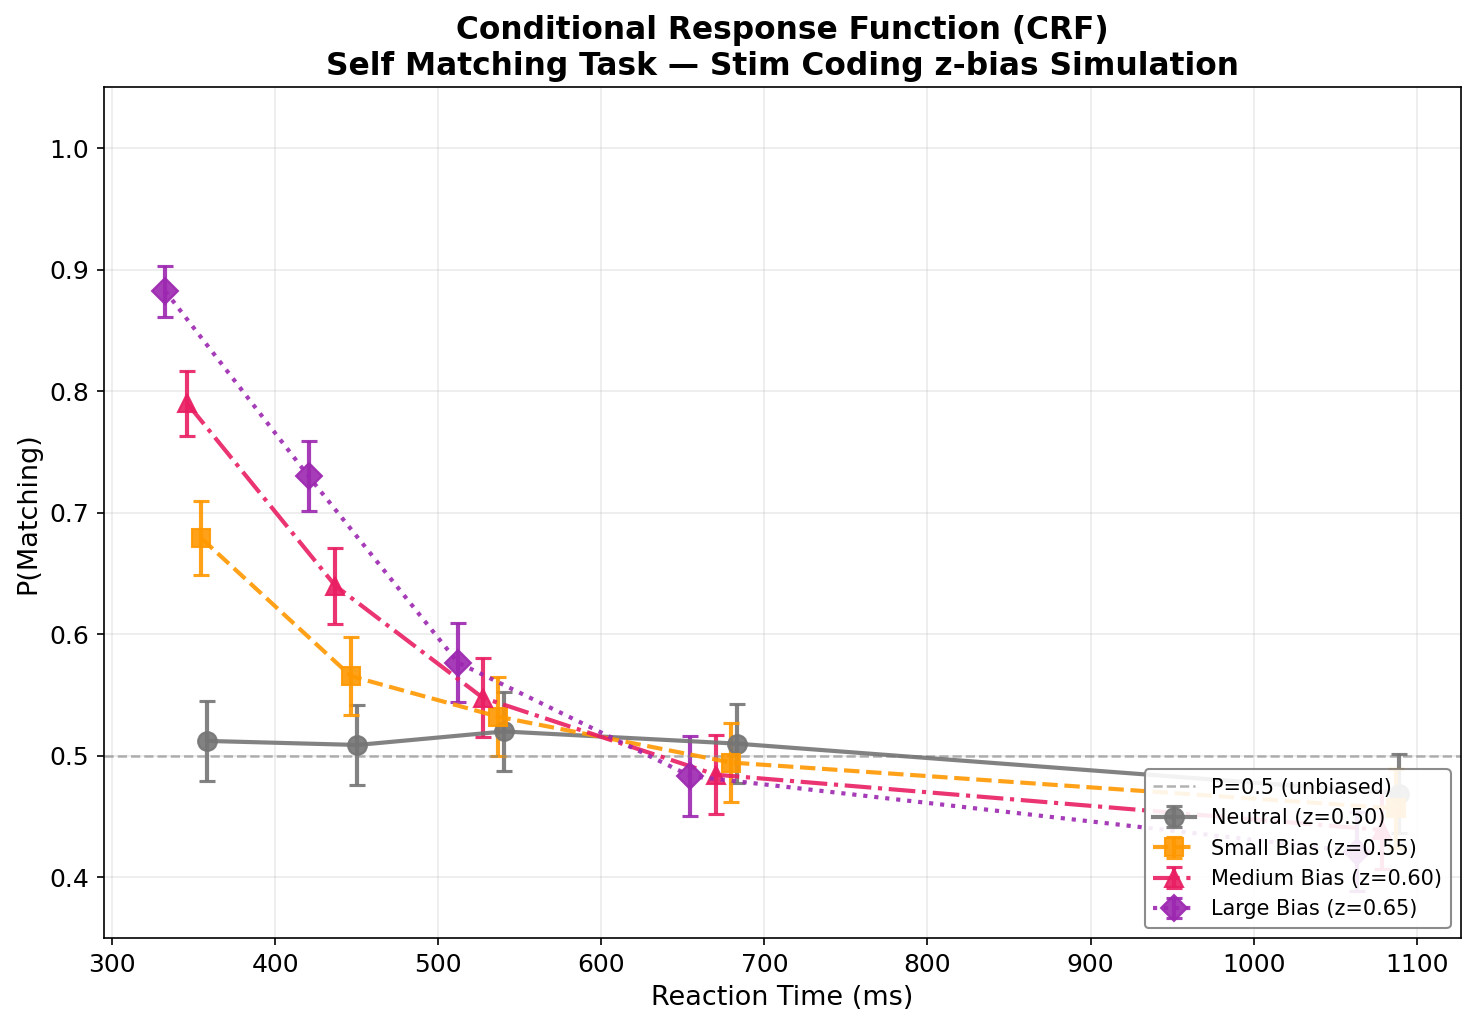

Saved: /home/jovyan/work/3_Figures/HDDM_Stim-Coding_Simulation/figure_01_CRF_zbias_main.png


In [5]:
# ============================================================================
# Cell 5: 图 1 — 主 CRF 图
# ============================================================================

condition_config = {
    'neutral':        {'label': 'Neutral (z=0.50)',        'color': '#757575', 'marker': 'o', 'ls': '-'},
    'z_bias_small':   {'label': 'Small Bias (z=0.55)',    'color': '#ff9800', 'marker': 's', 'ls': '--'},
    'z_bias_medium':  {'label': 'Medium Bias (z=0.60)',   'color': '#e91e63', 'marker': '^', 'ls': '-.'},
    'z_bias_large':   {'label': 'Large Bias (z=0.65)',    'color': '#9c27b0', 'marker': 'D', 'ls': ':'},
}

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 15, 'axes.titleweight': 'bold',
    'axes.labelsize': 13, 'legend.fontsize': 10, 'figure.dpi': 150,
})

fig, ax = plt.subplots(figsize=(10, 7))

for cond, cfg in condition_config.items():
    cdf = crf_df[crf_df['condition'] == cond]
    if len(cdf) == 0:
        continue
    ax.errorbar(
        cdf['rt_mean_ms'], cdf['p_matching'],
        yerr=[cdf['p_matching'] - cdf['ci_lo'], cdf['ci_hi'] - cdf['p_matching']],
        marker=cfg['marker'], linestyle=cfg['ls'], color=cfg['color'],
        linewidth=2, markersize=9, capsize=4, capthick=1.5,
        label=cfg['label'], alpha=0.9
    )

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.6,
           label='P=0.5 (unbiased)')
ax.set_xlabel('Reaction Time (ms)')
ax.set_ylabel('P(Matching)')
ax.set_title('Conditional Response Function (CRF)\n'
             'Self Matching Task — Stim Coding z-bias Simulation',
             fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')
ax.set_ylim(0.35, 1.05)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.tight_layout()
path_main = FIG_DIR / 'figure_01_CRF_zbias_main.png'
fig.savefig(path_main, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {path_main}")

---

## Cell 6: 图2 — RT 分布 + 匹配概率条形图

左: 各 z 水平的 RT 分布 (密度估计)
右: 中位 RT bin 处的 P(Matching)


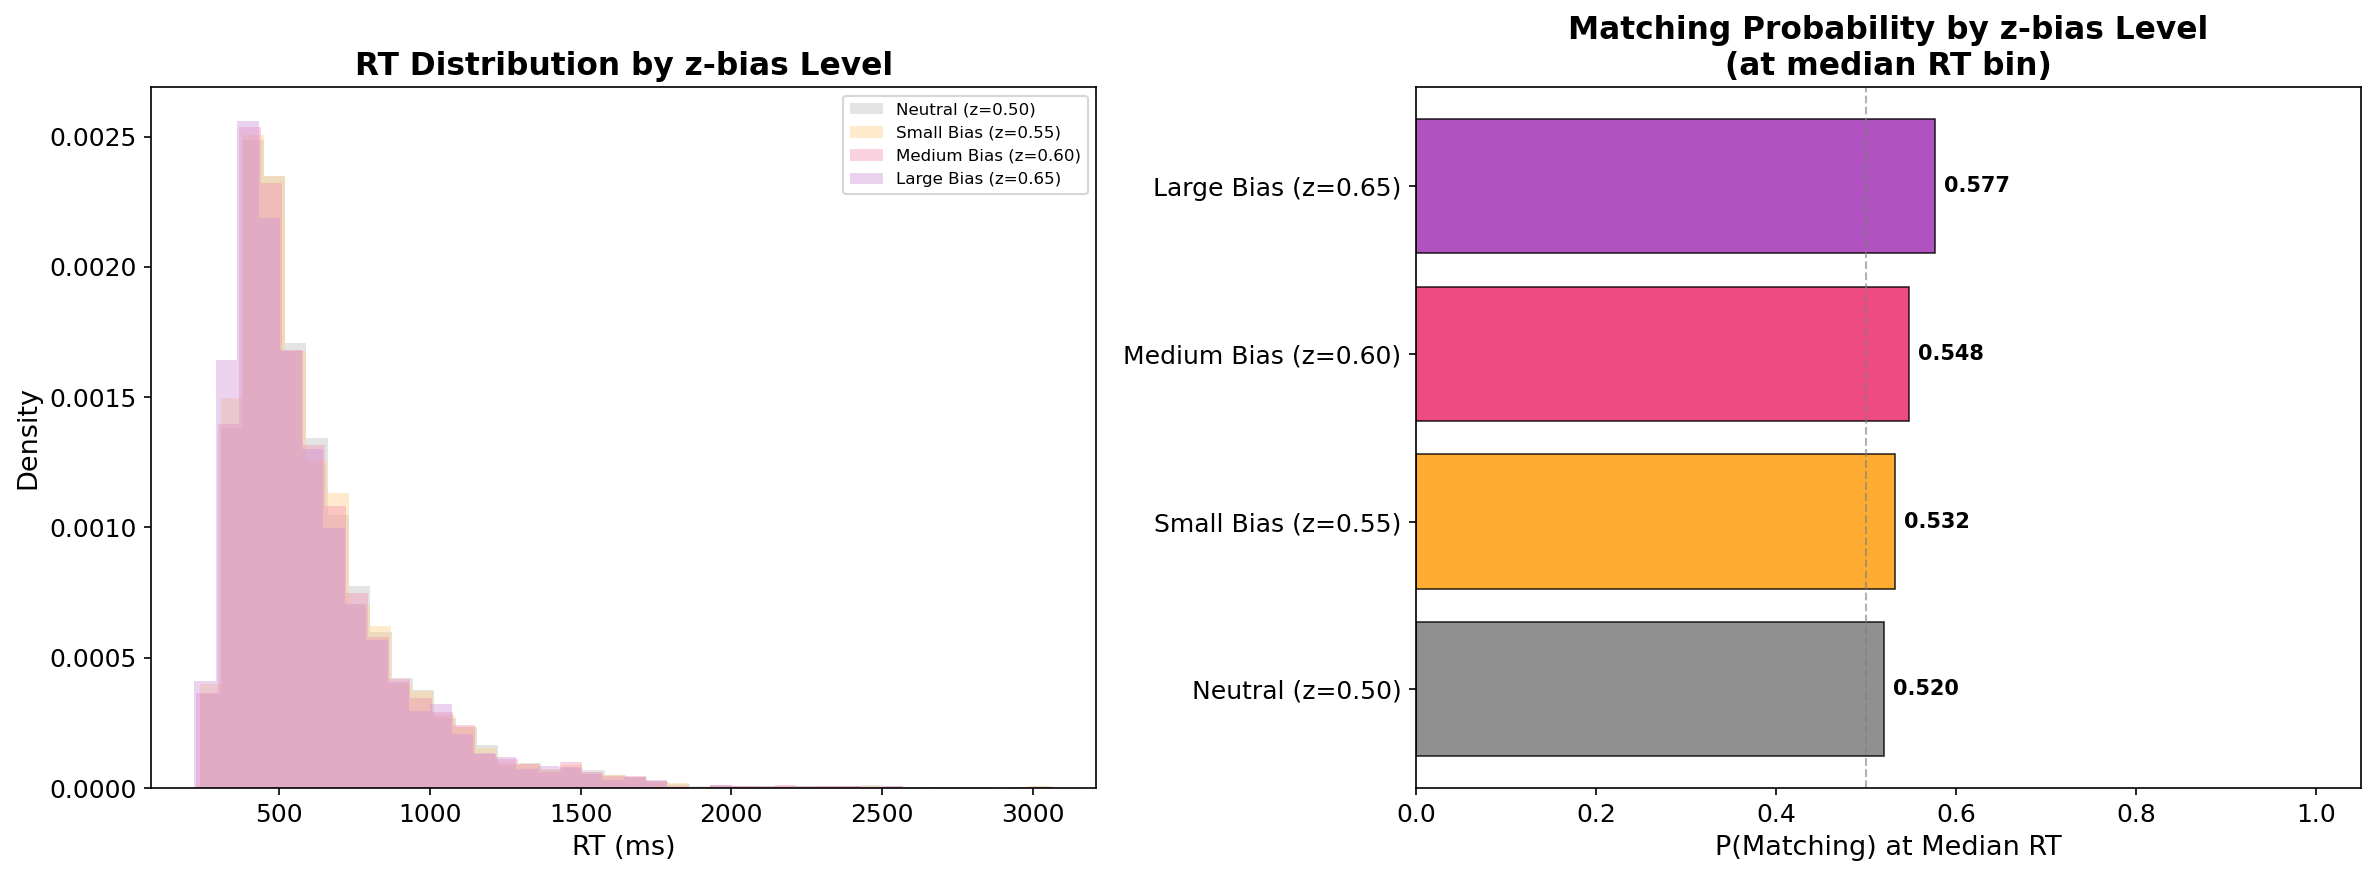

Saved: /home/jovyan/work/3_Figures/HDDM_Stim-Coding_Simulation/figure_02_CRF_RT_distribution.png


In [6]:
# ============================================================================
# Cell 6: 图 2 — RT 分布 + 匹配概率条形图
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: RT 分布
ax = axes[0]
colors_dist = {
    'neutral':       '#bdbdbd',
    'z_bias_small':  '#ffcc80',
    'z_bias_medium': '#f48fb1',
    'z_bias_large':  '#ce93d8',
}
for cond, color in colors_dist.items():
    cdf_rt = data[data['condition'] == cond]['rt'] * 1000
    ax.hist(cdf_rt, bins=40, alpha=0.4, color=color,
            label=condition_config[cond]['label'], density=True)
ax.set_xlabel('RT (ms)')
ax.set_ylabel('Density')
ax.set_title('RT Distribution by z-bias Level', fontweight='bold')
ax.legend(fontsize=8)

# 右: 中位 P(Matching)
ax = axes[1]
median_rt_data = []
for cond, cfg in condition_config.items():
    cdf = crf_df[crf_df['condition'] == cond]
    if len(cdf) > 0:
        median_bin = cdf.iloc[len(cdf) // 2]
        median_rt_data.append({
            'condition': cfg['label'],
            'rt_ms': median_bin['rt_mean_ms'],
            'p_matching': median_bin['p_matching'],
            'color': cfg['color'],
        })
med_df = pd.DataFrame(median_rt_data)
bars = ax.barh(
    med_df['condition'], med_df['p_matching'],
    color=med_df['color'], alpha=0.8, edgecolor='black', linewidth=0.8
)
for bar, p in zip(bars, med_df['p_matching']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{p:.3f}', va='center', fontsize=10, fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('P(Matching) at Median RT')
ax.set_title('Matching Probability by z-bias Level\n(at median RT bin)', fontweight='bold')
ax.set_xlim(0, 1.05)

plt.tight_layout()
path_dist = FIG_DIR / 'figure_02_CRF_RT_distribution.png'
fig.savefig(path_dist, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {path_dist}")

---

## Cell 7: 图3 — SPE 条形图

SPE = P(Matching|z_bias) − P(Matching|neutral)，反映 z-bias 的净效应量


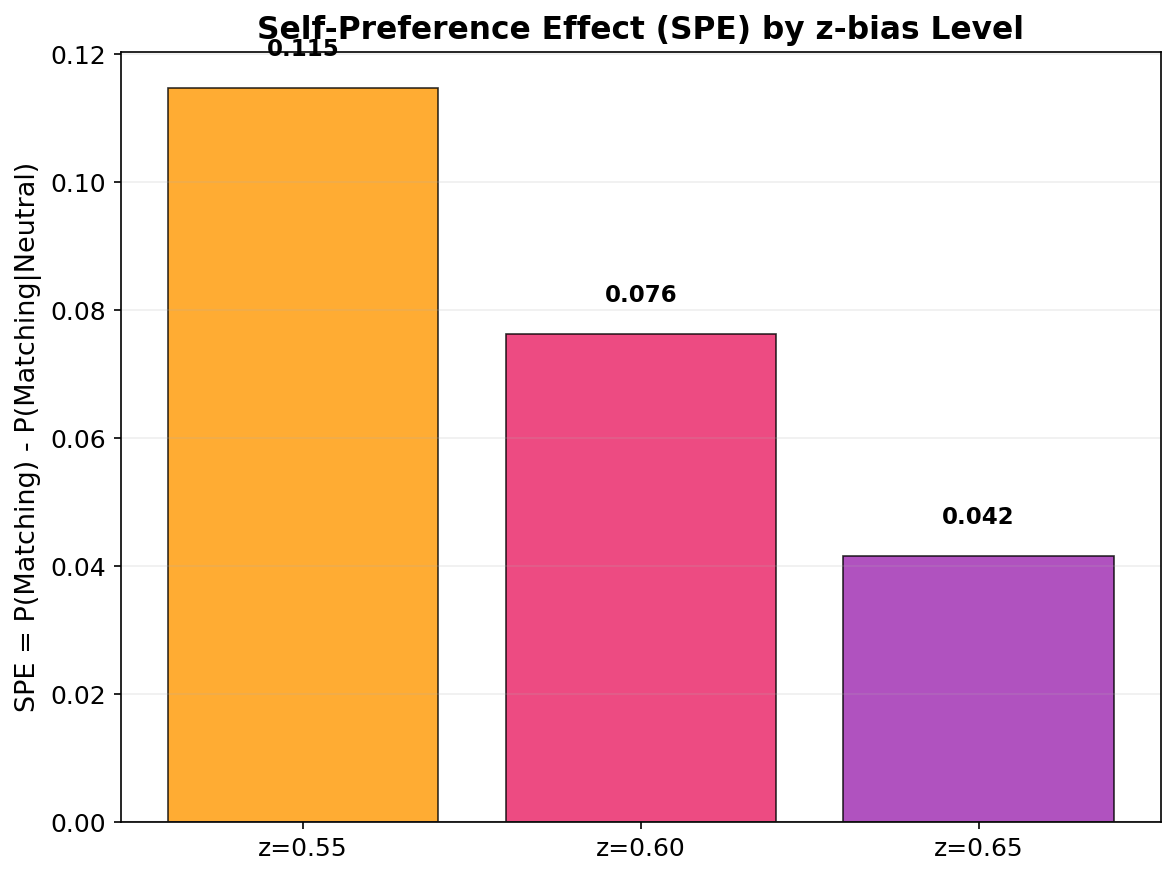

Saved: /home/jovyan/work/3_Figures/HDDM_Stim-Coding_Simulation/figure_03_SPE_by_zbias.png


In [7]:
# ============================================================================
# Cell 7: 图 3 — SPE 条形图
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

summary = crf_df.groupby('condition').agg(
    mean_p=('p_matching', 'mean'),
    se_p=('p_matching', lambda x: np.std(x) / np.sqrt(len(x))),
    mean_rt=('rt_mean_ms', 'mean'),
).reset_index()

neutral_p = summary.loc[summary['condition'] == 'neutral', 'mean_p'].values
if len(neutral_p) > 0:
    neutral_p = neutral_p[0]
    summary['SPE'] = summary['mean_p'] - neutral_p
    bias_conds = summary[summary['condition'] != 'neutral']

    z_values = [0.55, 0.60, 0.65]
    colors_spe = ['#ff9800', '#e91e63', '#9c27b0']
    labels_spe = ['z=0.55', 'z=0.60', 'z=0.65']

    for z, color, label, (_, row) in zip(
        z_values, colors_spe, labels_spe, bias_conds.iterrows()
    ):
        ax.bar(label, row['SPE'], color=color, alpha=0.8,
               edgecolor='black', linewidth=0.8)
        ax.text(label, row['SPE'] + 0.005, f"{row['SPE']:.3f}",
                ha='center', fontsize=11, fontweight='bold')

    ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.6)
    ax.set_ylabel('SPE = P(Matching) - P(Matching|Neutral)')
    ax.set_title('Self-Preference Effect (SPE) by z-bias Level',
                 fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    path_spe = FIG_DIR / 'figure_03_SPE_by_zbias.png'
    fig.savefig(path_spe, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {path_spe}")
else:
    print("No neutral condition data found.")

---

## 输出文件清单

| 文件 | 位置 | 说明 |
|------|------|------|
| `simulation_zbias_crf_data.csv` | `2_Data/Generate_Data/HDDM_Stim-Coding_Simulation/` | 18,000 试次仿真数据 |
| `simulation_zbias_subject_params.csv` | `2_Data/Generate_Data/HDDM_Stim-Coding_Simulation/` | 30 被试 DDM 参数 |
| `crf_results_zbias.csv` | `2_Data/Generate_Data/HDDM_Stim-Coding_Simulation/` | CRF 分箱结果 |
| `figure_01_CRF_zbias_main.png` | `3_Figures/HDDM_Stim-Coding_Simulation/` | 主 CRF 图 |
| `figure_02_CRF_RT_distribution.png` | `3_Figures/HDDM_Stim-Coding_Simulation/` | RT 分布 + 匹配概率 |
| `figure_03_SPE_by_zbias.png` | `3_Figures/HDDM_Stim-Coding_Simulation/` | SPE 条形图 |

---

**生成日期**: 2026-06-08
**仿真工具**: DockerHDDM (HDDM 1.0.1RC)
**理论框架**: Stim Coding z-bias 仿真
